In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))
from src.utils import load_full_config
from src.model import SimpleTransformer

In [2]:
# Load data and extract consecutive pairs
cfg = load_full_config()
next_token_data_path = os.path.join('..', cfg['paths']['next_token_data_path'])
checkpoint = torch.load(next_token_data_path)
X = checkpoint['X']

# Extract (X_t, X_{t+1}) pairs for ground truth
X_t_list = []
X_t1_list = []
num_samples = min(1000, len(X))
for i in range(num_samples):
    seq = X[i].squeeze().numpy()
    X_t_list.extend(seq[:-1])
    X_t1_list.extend(seq[1:])

X_t = np.array(X_t_list)
X_t1_true = np.array(X_t1_list)


In [3]:
# Load model and get predictions
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleTransformer(**cfg['architecture'])

model_path = os.path.join('..', cfg['paths']['save_dir'], cfg['paths']['next_token_model_name'])
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
else:
    raise FileNotFoundError(f"Model not found at {model_path}. Please train first.")

# Get model predictions for the same sequences
X_t_pred_list = []
X_t1_pred_list = []

with torch.no_grad():
    for i in range(num_samples):
        seq = X[i:i+1].to(device)  # Shape: (1, 100, 1)
        pred, _ = model(seq)
        pred_np = pred[0, :, 0].cpu().numpy()
        seq_np = seq.squeeze().cpu().numpy()
        X_t_pred_list.extend(seq_np[:-1])
        X_t1_pred_list.extend(pred_np[:-1])  # pred[t] predicts X[t+1]

X_t_pred = np.array(X_t_pred_list)
X_t1_pred = np.array(X_t1_pred_list)


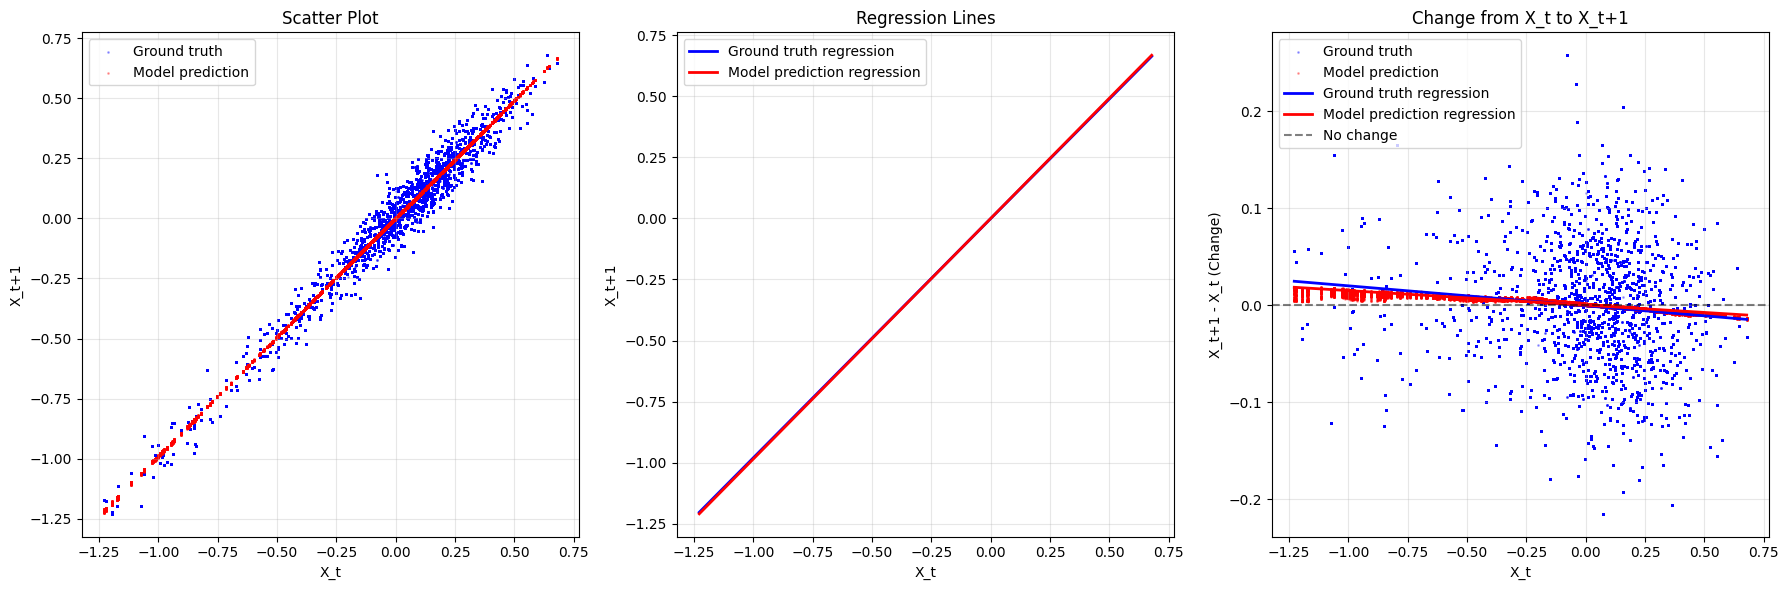

In [4]:
# Fit regression lines
slope_true, intercept_true = np.polyfit(X_t, X_t1_true, 1)
slope_pred, intercept_pred = np.polyfit(X_t_pred, X_t1_pred, 1)

X_t_line = np.linspace(X_t.min(), X_t.max(), 100)
X_t1_line_true = slope_true * X_t_line + intercept_true
X_t1_line_pred = slope_pred * X_t_line + intercept_pred

# Calculate differences from X_t
diff_true = X_t1_true - X_t
diff_pred = X_t1_pred - X_t_pred
diff_line_true = X_t1_line_true - X_t_line
diff_line_pred = X_t1_line_pred - X_t_line

# Create 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Subplot 1: Scatter plot
axes[0].scatter(X_t, X_t1_true, alpha=0.3, s=1, color='blue', label='Ground truth')
axes[0].scatter(X_t_pred, X_t1_pred, alpha=0.3, s=1, color='red', label='Model prediction')
axes[0].set_xlabel('X_t')
axes[0].set_ylabel('X_t+1')
axes[0].set_title('Scatter Plot')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Subplot 2: Regression lines
axes[1].plot(X_t_line, X_t1_line_true, 'b-', linewidth=2, label='Ground truth regression')
axes[1].plot(X_t_line, X_t1_line_pred, 'r-', linewidth=2, label='Model prediction regression')
axes[1].set_xlabel('X_t')
axes[1].set_ylabel('X_t+1')
axes[1].set_title('Regression Lines')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Subplot 3: Difference plot
axes[2].scatter(X_t, diff_true, alpha=0.3, s=1, color='blue', label='Ground truth')
axes[2].scatter(X_t_pred, diff_pred, alpha=0.3, s=1, color='red', label='Model prediction')
axes[2].plot(X_t_line, diff_line_true, 'b-', linewidth=2, label='Ground truth regression')
axes[2].plot(X_t_line, diff_line_pred, 'r-', linewidth=2, label='Model prediction regression')
axes[2].axhline(y=0, color='k', linestyle='--', alpha=0.5, label='No change')
axes[2].set_xlabel('X_t')
axes[2].set_ylabel('X_t+1 - X_t (Change)')
axes[2].set_title('Change from X_t to X_t+1')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


[ 0.          0.02564726  0.05683898  0.01117554  0.08956765 -0.01357974
 -0.11023426 -0.10669787 -0.03547196 -0.08086795 -0.08652885 -0.06640033
 -0.06740055 -0.00299505 -0.03793124 -0.03750458  0.01545887 -0.00532953
  0.00936062  0.12076557  0.07997023  0.09522441  0.05288396  0.02979331
 -0.06334604 -0.07242606 -0.01698085  0.04242338  0.06988908  0.04710787
  0.01396378 -0.01797536 -0.04876484 -0.03664731  0.01644689 -0.00084489
 -0.07785842 -0.07665645 -0.09336185 -0.04184521 -0.03580559 -0.05842724
 -0.11628829 -0.10797276 -0.07188012 -0.03206379 -0.02245498  0.0623238
  0.10603839  0.13362655  0.2628308   0.26679942  0.1872929   0.19770616
  0.18613742  0.1678289   0.20809442  0.1730833   0.2211012   0.25881582
  0.2551679   0.14016196  0.15615888  0.15050259  0.08846806  0.19029525
  0.24574131  0.2265191   0.24497442  0.3836727   0.3807864   0.31056815
  0.3263589   0.28276634  0.36853907  0.32839882  0.26149458  0.16080973
  0.20130126  0.17299908  0.10966046  0.03103057  0.

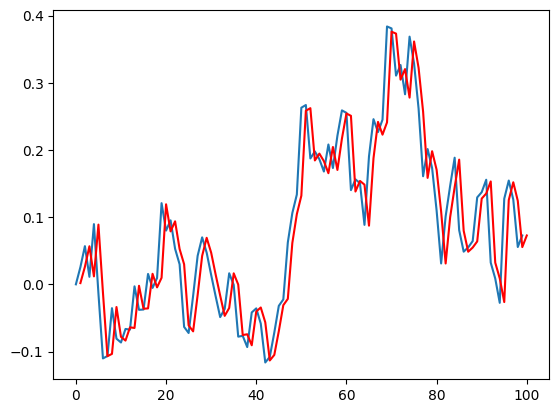

In [5]:
i = 0
seq = X[i:i+1].to(device)
pred, _ = model(seq)
pred_mean_np = pred[0, :, 0].detach().cpu().numpy()
print(seq.squeeze().numpy())
print(pred_mean_np)
timesteps = np.arange(1, len(pred_mean_np) + 1)
plt.plot(seq.squeeze().numpy())
plt.plot(timesteps, pred_mean_np, color='red')
plt.show()